# 17 — HID-search-v2: better automatic proposals in the same exact language

Notebook 16 ended with a **negative** prespecified result: the HID-v1 search did not beat
the nine-codec portfolio on the structured confirmation population, although every
archive decoded exactly. A post-hoc probe (bitacora 39) then found short, legal,
input-only descriptions on noisy-period strings that the frozen search had missed.

This notebook presents the prospective test of that lead. The wire format, decoder,
baselines, generators and the legacy search are **unchanged**; only the proposals are
new, and every arm pays for its own complete computation, including a fresh legacy run.
Everything below is read from saved artefacts.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /private/tmp/hid_review_closure_20261003/baseline/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
for _p in (os.path.join(os.path.dirname(ROOT), "src"), ROOT):
    while _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("hierarchy", None)          # a sibling repo ships a module "hierarchy"
import json, collections
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from hierarchy.decode import decode_archive
from hierarchy.ledger import archive_ledger, field_buckets, BUCKETS
from hierarchy.search_v2 import ARMS, infer_v2

BASE = Path(ROOT) / "results" / "hierarchy_search_v2"
RUN = BASE / "search-confirm-v2-r1"
REG = BASE / "development" / "dev-search-v2-regression"
OLD = Path(ROOT) / "results" / "hierarchy_v1" / "confirm-v1-r1"
freeze = json.loads((RUN / "freeze.json").read_text())
summary = json.loads((RUN / "summary.json").read_text())
claims = json.loads((RUN / "claim_ledger.json").read_text())
diag = json.loads((RUN / "diagnostics.json").read_text())
audit = json.loads((RUN / "arithmetic_audit.json").read_text())
verification = json.loads((RUN / "verification.json").read_text())
rows = [json.loads(x) for x in (RUN / "cases.jsonl").read_text().splitlines() if x.strip()]
by_case = collections.defaultdict(dict)
for r in rows:
    by_case[r["case_id"]][r["method"]] = r
ARM_ORDER = list(ARMS)
print("run:", freeze["run_id"], "| study:", freeze["study"], "| frozen", freeze["frozen_at_utc"])
print("rows:", len(rows), "| cases:", len(by_case),
      "| engineering:", summary["engineering_status"], "| complete:", summary["study_complete"])

ImportError: artifact-only harness: import of hierarchy.search_v2 refused

## 1. The historical result that motivated this stage

The accepted HID-v1 primary result (correctness replay `confirm-v1-r1`), read from its
stored summary. It is a valid negative result about one search, not an impossibility
theorem.

In [3]:
old = json.loads((OLD / "summary.json").read_text())["primary"]
print("HID-v1 primary verdict:", old["verdict"])
print("estimate (bits saved per input bit):", old["estimate_mean_saving_per_input_bit"])
print("95% interval:", old["ci95"])

HID-v1 primary verdict: not_supported
estimate (bits saved per input bit): -0.044615638178146094
95% interval: [-0.053677526971600935, -0.035824263694091044]


## 2. Exposure status and provenance

The reserved namespaces were generated only after the freeze; the freeze records an
exposure scan of every generated artefact under the study root, the complete executable
closure (import-probe verified) and a snapshot tar.

In [4]:
print("exposure check clean:", freeze["exposure_check"]["clean"])
print("files outside the closure loaded by the import probe:", freeze["import_probe"]["outside_closure"])
print("closure files frozen:", len(freeze["source_sha256"]), "| protocol files:", len(freeze["protocol_sha256"]))
print("snapshot members:", freeze["snapshot"]["members"], "| sha256", freeze["snapshot"]["sha256"][:16], "...")
print("design:", {r: v for r, v in freeze["design"]["expected"].items()},
      "| total strings", freeze["design"]["expected_total_strings"],
      "| total rows", freeze["design"]["expected_total_rows"])

exposure check clean: True
files outside the closure loaded by the import probe: []
closure files frozen: 28 | protocol files: 9
snapshot members: 76 | sha256 6766f967012b97f3 ...
design: {'confirmation': {'rows': 23040, 'strings': 1440, 'units': 720}, 'stress': {'rows': 1024, 'strings': 64, 'units': 32}, 'transfer': {'rows': 4608, 'strings': 288, 'units': 144}} | total strings 1792 | total rows 28672


## 3. The six cumulative arms, on a tiny hand-made input

Stages: **L** legacy search; **P** first-block template, old period grid, 1,024-bit local
patches; **C** consensus template (per-phase majority) on the same grid; **D** the other
periods up to 256; **G** one global correction list; **B** bounded input-only boundary
search. Each arm keeps the smallest complete archive; ties keep the earlier one.
Below, a period-63 word with noise (63 is not on the old grid) — built here, so its
truth is known to us and never passed to the encoder.

In [5]:
import random
rng = random.Random(63)
word = "".join(rng.choice("01") for _ in range(63))
n = 4096
clean = (word * (n // 63 + 1))[:n]
flips = sorted(rng.sample(range(n), n // 32))
x = "".join(("1" if c == "0" else "0") if i in set(flips) else c for i, c in enumerate(clean))
print(f"input: n = {n} bits, period 63 word with {len(flips)} flipped positions")
for name in ARM_ORDER:
    r = infer_v2(x, ARMS[name])
    assert decode_archive(r.archive) == x
    print(f"{name:<20} {r.archive_bits:>6} bits  selected stage {r.selected_stage:<4}"
          f" detail {r.telemetry.get('selected_detail')}")

input: n = 4096 bits, period 63 word with 128 flipped positions


hid_legacy             4168 bits  selected stage raw  detail None


hid_first_local        4168 bits  selected stage raw  detail None


hid_consensus_local    4168 bits  selected stage raw  detail None


hid_dense_local        1944 bits  selected stage D    detail {'period': 63, 'errors': 128}


hid_global             1320 bits  selected stage G    detail {'period': 63, 'errors': 128}


hid_full               1320 bits  selected stage G    detail {'period': 63, 'errors': 128}


In [6]:
r = infer_v2(x, ARMS["hid_global"])
led = archive_ledger(r.archive)
print("exact cost buckets (bits):", field_buckets(r.archive))
for i, rule in enumerate(led["model"].rules):
    print(i, type(rule).__name__, {k: (v if not isinstance(v, (tuple, str)) or len(v) < 12 else f"<{len(v)} items>")
                                   for k, v in rule.__dict__.items()})

exact cost buckets (bits): {'envelope': 72, 'dag_count_opcodes': 48, 'references': 32, 'parameters': 48, 'literal_payload_bits': 64, 'literal_padding_bits': 8, 'correction_deltas': 1048, 'other_payload': 0}
0 Literal {'bits': '<63 items>'}
1 Repeat {'child': 0, 'copies': 65}
2 Literal {'bits': '1'}
3 Concat {'children': (1, 2)}
4 Patch {'child': 3, 'positions': '<128 items>'}


## 4. Prospective population and counts

Expected versus present rows per role, and the status of every row. Resource fallbacks
(`timeout_raw`, `rss_limit_raw`) are deployed outcomes and stay in the population.

In [7]:
v = summary["validation"]
print("expected rows", v["expected_rows"], "| present", v["present_rows"],
      "| archives checked", v["archives_checked"], "| distinct decoded", v["distinct_archives_decoded"])
for role, per in summary["status_rates"].items():
    print(role, {m: {k: c for k, c in d.items() if k != "expected"} for m, d in per.items()
                 if m.startswith("hid") or m == "baseline_best"})
print("nesting:", summary["nesting"])

expected rows 28672 | present 28672 | archives checked 28672 | distinct decoded 17573
confirmation {'hid_legacy': {'ok': 1440}, 'hid_first_local': {'ok': 1440}, 'hid_consensus_local': {'ok': 1440}, 'hid_dense_local': {'ok': 1440}, 'hid_global': {'ok': 1440}, 'hid_full': {'ok': 1440}, 'baseline_best': {'ok': 1440}}
transfer {'hid_legacy': {'ok': 288}, 'hid_first_local': {'ok': 288}, 'hid_consensus_local': {'ok': 288}, 'hid_dense_local': {'ok': 288}, 'hid_global': {'ok': 288}, 'hid_full': {'ok': 288}, 'baseline_best': {'ok': 288}}
stress {'hid_legacy': {'ok': 64}, 'hid_first_local': {'ok': 64}, 'hid_consensus_local': {'ok': 64}, 'hid_dense_local': {'ok': 64}, 'hid_global': {'ok': 64}, 'hid_full': {'ok': 64}, 'baseline_best': {'ok': 64}}
nesting: {'nesting_pairs_checked': 8960, 'resource_nesting_break_count': 0}


## 5. Primary endpoint and its gates

Confirmation F01–F06, F12; three sizes; twenty paired base/ragged units per cell;
$s(x) = (\text{bits(portfolio)} - \text{bits(hid\_full)})/n$, averaged within units,
within cells, then over the 21 cells equally. Positive favours HID-search-v2.

In [8]:
p = summary["primary"]
print("gate:", {k: p["gate"][k] for k in ("engineering_valid", "complete", "censored_count", "assessable")})
print("cells", p.get("cells"), "| paired units", p.get("units"), "| strings", p.get("strings"))
print("estimate (bits per input bit):", p.get("estimate_mean_saving_per_input_bit"))
print("95% percentile interval:", p.get("ci95"))
print("VERDICT:", p["verdict"])
print("strings HID better / tied / worse:", p.get("strings_hid_better"), p.get("strings_tied"), p.get("strings_hid_worse"))
print("independent arithmetic audit:", {k: audit[k] for k in ("independent_estimate", "abs_difference", "all_checks_pass")})

gate: {'engineering_valid': True, 'complete': True, 'censored_count': 0, 'assessable': True}
cells 21 | paired units 420 | strings 840
estimate (bits per input bit): 0.005605234982532739
95% percentile interval: [-0.0020814318519917223, 0.01304720625259862]
VERDICT: inconclusive
strings HID better / tied / worse: 297 72 471
independent arithmetic audit: {'independent_estimate': 0.005605234982532739, 'abs_difference': 0.0, 'all_checks_pass': True}


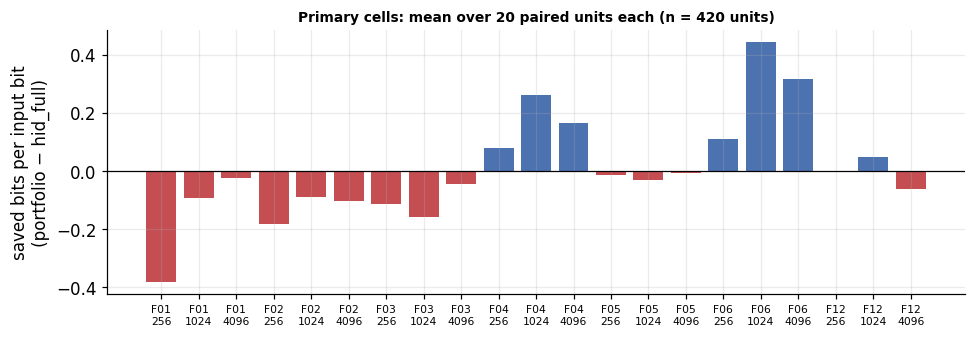

In [9]:
cells = [c for c in summary["cells"]["confirmation"] if c["family"] in p["families"]]
fig, ax = plt.subplots(figsize=(9, 3.2))
labels = [f"{c['family']}\n{c['base_length']}" for c in cells]
vals = [c["vs_portfolio"].get("mean_per_input_bit", np.nan) for c in cells]
ax.bar(range(len(cells)), vals, color=["#4c72b0" if v >= 0 else "#c44e52" for v in vals])
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(cells)), labels, fontsize=7)
ax.set_ylabel("saved bits per input bit\n(portfolio − hid_full)")
ax.set_title(f"Primary cells: mean over 20 paired units each (n = {sum(c['vs_portfolio']['units_complete'] for c in cells)} units)", fontsize=9)
plt.tight_layout(); plt.show()

## 6. Five targeted cumulative contrasts (99% intervals)

Each contrast adds one stage and is read on its target family only (F06 for P, C, D, G;
F12 for B), from one joint bootstrap draw. They are cumulative algorithm changes,
including their cost: not additive, not pure mechanism effects, and a positive contrast
cannot rescue a negative primary result.

In [10]:
for k, c in summary["contrasts"].items():
    print(f"{k:<12} {c['family']}  estimate {c.get('estimate_per_input_bit')}  99% CI {c.get('ci99')}  "
          f"reading {c['reading']}  units {c.get('units')}")

P_vs_L       F06  estimate 0.01425259495456209  99% CI [0.0011714461606489386, 0.03442815185804962]  reading supported  units 60
C_vs_P       F06  estimate 0.12214205654204006  99% CI [0.07057285239481416, 0.17494166833718625]  reading supported  units 60
D_vs_C       F06  estimate 0.09959053921404402  99% CI [0.03705879100298928, 0.17023339569408483]  reading supported  units 60
G_vs_D       F06  estimate 0.045633231033071285  99% CI [0.03891882329385152, 0.052189814522774804]  reading supported  units 60
B_full_vs_G  F12  estimate 0.12025781469716568  99% CI [0.1128727700538363, 0.12762753354490694]  reading supported  units 60


## 7. Descriptive transfer and parameter-shift stress (no verdicts)

In [11]:
for key in ("all_family_confirmation", "structured_transfer", "all_stress"):
    t = summary.get(key) or {}
    print(f"{key:<25} vs portfolio {t.get('full_vs_portfolio')} CI {t.get('full_vs_portfolio_ci95')} | "
          f"vs legacy {t.get('full_vs_legacy')} | units {t.get('units')} of {t.get('required_units')}")
print("structured transfer by size:", json.dumps(summary["transfer_by_size"], indent=0))
for c in summary["cells"].get("stress", []):
    print("stress", c["family"], c["base_length"], "vs portfolio", c["vs_portfolio"].get("mean_per_input_bit"),
          "| vs legacy", c["vs_legacy"].get("mean_per_input_bit"))

all_family_confirmation   vs portfolio -0.07295166658828228 CI [-0.07923298783869345, -0.06666822984112483] | vs legacy 0.0343527145768518 | units 720 of 720
structured_transfer       vs portfolio 0.0003706132677265279 CI [-0.0034540810186953035, 0.004260139039875997] | vs legacy 0.055012302290607794 | units 84 of 84
all_stress                vs portfolio 0.1740817188056191 CI [0.15137527522468608, 0.19357527507459218] | vs legacy 0.2932620845647139 | units 32 of 32
structured transfer by size: {
"16384": {
"full_vs_portfolio": 0.00173524286353131,
"full_vs_portfolio_units_unavailable": 0,
"full_vs_legacy": 0.0679435767559106,
"full_vs_legacy_units_unavailable": 0,
"note": "estimate only; structured families; equal cell weights"
},
"65536": {
"full_vs_portfolio": -0.0015737970842687149,
"full_vs_portfolio_units_unavailable": 0,
"full_vs_legacy": 0.04390724965850869,
"full_vs_legacy_units_unavailable": 0,
"note": "estimate only; structured families; equal cell weights"
},
"131072": {
"f

## 8. Where the bits go: exact cost components

Every deployed archive is cut into exhaustive, mutually exclusive field buckets whose sum
is exactly 8 × its byte length. Removing a bucket "on paper" is not a deployable code.

In [12]:
for k, c in summary["cost_components"].items():
    if not isinstance(c, dict) or "mean_bits" not in c:
        continue
    mb = c["mean_bits"]
    print(f"{k:<34} archives {c['archives']:>4}  mean total {c['mean_total_bits']:>9.1f}  " +
          "  ".join(f"{b[:10]}={mb[b]:.0f}" for b in BUCKETS))

confirmation|baseline_best         archives 1440  mean total     879.7  envelope=66  dag_count_=0  references=0  parameters=0  literal_pa=202  literal_pa=0  correction=0  other_payl=611
confirmation|hid_full              archives 1440  mean total     983.3  envelope=66  dag_count_=39  references=81  parameters=60  literal_pa=694  literal_pa=5  correction=38  other_payl=0
confirmation|hid_legacy            archives 1440  mean total    1063.8  envelope=67  dag_count_=43  references=87  parameters=70  literal_pa=768  literal_pa=5  correction=24  other_payl=0
stress|baseline_best               archives   64  mean total   17295.4  envelope=76  dag_count_=0  references=0  parameters=0  literal_pa=128  literal_pa=0  correction=0  other_payl=17091
stress|hid_full                    archives   64  mean total   15029.4  envelope=75  dag_count_=94  references=79  parameters=112  literal_pa=9072  literal_pa=17  correction=5580  other_payl=0
stress|hid_legacy                  archives   64  mean to

## 9. Stage yield and resource events

In [13]:
for k, t in summary["stage_telemetry"].items():
    if k.startswith("confirmation|hid_full") or k.startswith("transfer|hid_full") or k.startswith("stress|hid_full"):
        print(k, "| rows", t["rows"], "| selected", t["selected_stage"],
              "| B caps", t["B_cap_hit"], "| B stops", t["B_stop_reason"])
print("resource nesting breaks:", summary["nesting"]["resource_nesting_break_count"])
res = summary["resources"]
for m in ARM_ORDER:
    r_ = res.get(m, {})
    print(f"{m:<20} median encode {r_.get('encode_s_median')}  max {r_.get('encode_s_max')}  peak RSS MB {r_.get('peak_rss_mb_max')}")

confirmation|hid_full | rows 1440 | selected {'L': 675, 'raw': 547, 'B': 120, 'C': 32, 'G': 56, 'D': 10} | B caps 22 | B stops {'no_strict_improvement': 1418, 'root_trial_cap': 22}
stress|hid_full | rows 64 | selected {'G': 32, 'B': 27, 'L': 5} | B caps 2 | B stops {'no_strict_improvement': 62, 'root_trial_cap': 2}
transfer|hid_full | rows 288 | selected {'L': 205, 'G': 24, 'raw': 54, 'B': 5} | B caps 6 | B stops {'no_strict_improvement': 282, 'root_trial_cap': 3, 'leaf_length_charge_cap': 3}
resource nesting breaks: 0
hid_legacy           median encode 0.238144875  max 9.819112042  peak RSS MB 316.453125
hid_first_local      median encode 0.238222042  max 9.730490583  peak RSS MB 315.96875
hid_consensus_local  median encode 0.2397083745  max 9.668657833  peak RSS MB 313.890625
hid_dense_local      median encode 0.243099708  max 9.68695325  peak RSS MB 315.15625
hid_global           median encode 0.2428825205  max 9.772918584  peak RSS MB 315.140625
hid_full             median encode 0

## 10. Supplied-boundary references: a restricted, evaluation-only diagnostic

For F12 and S02 strings the generator's construction cuts, mapped through its edits,
are used — after automatic encoding — to build one feasible partition with the same
leaf builder. Gap = (bits(hid_full) − min(reference, raw))/n; negative means the
automatic archive is shorter. This is not an oracle optimum and not a bound on search
error; it is never an incumbent.

In [14]:
sb = diag["supplied_boundary_references"]
print(sb["label"])
print("strings", sb["strings"], "| references available", sb["available"])
for k, v in sb["by_cell"].items():
    print(f"{k:<28} gap mean {v['gap_mean']}  median {v['gap_median']}  "
          f"auto shorter {v['automatic_shorter_than_reference']}  longer {v['automatic_longer_than_reference']}  ties {v['ties']}")

EVALUATION-ONLY supplied-boundary feasible references; truth used only after automatic encoding; not an oracle optimum or bound on search error
strings 176 | references available 176
confirmation|F12|1024        gap mean -0.07295901290165531  median -0.062317429406037  auto shorter 40  longer 0  ties 0
confirmation|F12|256         gap mean 0.0  median 0.0  auto shorter 0  longer 0  ties 40
confirmation|F12|4096        gap mean 0.10502920157736644  median 0.076171875  auto shorter 0  longer 40  ties 0
stress|S02|4096              gap mean 0.008664937332276164  median -0.021484375  auto shorter 12  longer 4  ties 0
stress|S02|65536             gap mean 0.029448726364599286  median 0.008422466012603182  auto shorter 7  longer 9  ties 0
transfer|F12|131072          gap mean 0.08341121437120774  median 0.0834941827198169  auto shorter 0  longer 8  ties 0
transfer|F12|16384           gap mean 0.1346904437814178  median 0.1196070055531824  auto shorter 0  longer 8  ties 0
transfer|F12|65536  

## 11. Verification and claim ledger

In [15]:
print("verification:", {k: verification.get(k) for k in ("engineering_status", "completeness", "exit_code")})
for c_ in verification.get("commands", []):
    print(f"  {c_['name']:<22} exit {c_['exit_code']}  {c_['tail'][-1] if c_['tail'] else ''}")
for c_ in claims:
    print(f"{c_['id']:<5} {c_['status']:<14} {c_['claim'][:100]}")

verification: {'engineering_status': 'valid', 'completeness': 'complete', 'exit_code': 0}
C1    inconclusive   HID-search-v2 (hid_full) yields an average code-length saving over the nine-baseline portfolio on fr
C2    supported      Every stored archive decodes exactly to its input with the independent decoder
C3.1  supported      P_vs_L: adding the stage that turns hid_legacy into hid_first_local saves code length on confirmatio
C3.2  supported      C_vs_P: adding the stage that turns hid_first_local into hid_consensus_local saves code length on co
C3.3  supported      D_vs_C: adding the stage that turns hid_consensus_local into hid_dense_local saves code length on co
C3.4  supported      G_vs_D: adding the stage that turns hid_dense_local into hid_global saves code length on confirmatio
C3.5  supported      B_full_vs_G: adding the stage that turns hid_global into hid_full saves code length on confirmation 
C4    descriptive    Descriptive: hid_full versus the portfolio on structured 

## What this study can and cannot say

* **Fresh instances, familiar generators.** The confirmation strings are new draws of the
  twelve declared families; this is not generalisation to unfamiliar structure.
* **One language, one resource policy.** Every number is a complete archive length under
  the unchanged HID-v1 format and the frozen budgets; it is not $K$, not a minimum over all
  programs, and not generator identification.
* **Contrasts are cumulative and costed.** A stage's contrast measures adding it to the
  previous arm under the same external limits, not a pure or additive mechanism effect.
* **Boundary references are restricted.** They use supplied metadata after encoding and a
  shortest-period leaf heuristic; they neither bound search error nor serve as a method.